<a href="https://colab.research.google.com/github/vision1011/Artificial-Intelligence-and-Machine-Learning/blob/main/LanguageTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:































# Cell 1: Import libraries and load the dataset
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import tensorflow as tf
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK components
nltk.download('stopwords')
nltk.download('wordnet')

# Path to teacher's dataset
file_path = "/content/drive/MyDrive/AI & Machine learning/Book_review.csv"
df = pd.read_csv(file_path)

# Standardize column names to fix potential KeyError
df.columns = df.columns.str.strip()
df = df[["rating", "reviewText", "summary"]].copy()

# Fill missing values and combine text columns
df["reviewText"] = df["reviewText"].astype(str)
df["summary"] = df["summary"].fillna("").astype(str)
df["text"] = df["summary"] + " " + df["reviewText"]

# Convert 1-5 star ratings into 3 classes: 0(neg), 1(neu), 2(pos)
def rating_to_sentiment(rating):
    if rating <= 2: return 0
    elif rating == 3: return 1
    else: return 2

df["label"] = df["rating"].apply(rating_to_sentiment)
target_names = ["negative", "neutral", "positive"]

print("Success! Data loaded. Total rows:", len(df))
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Success! Data loaded. Total rows: 12000


,rating,reviewText,summary,text,label
0,5,This book was the very first bookmobile book I...,50 + years ago...,50 + years ago... This book was the very first...,2
1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!,Boring! Boring! Boring! When I read the descri...,0
2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!,Wiggleliscious/new toy ready/!! I just had to ...,2
3,5,I don't normally buy 'mystery' novels because ...,Very good read.,Very good read. I don't normally buy 'mystery'...,2
4,5,"This isn't the kind of book I normally read, a...",Great Story!,Great Story! This isn't the kind of book I nor...,2


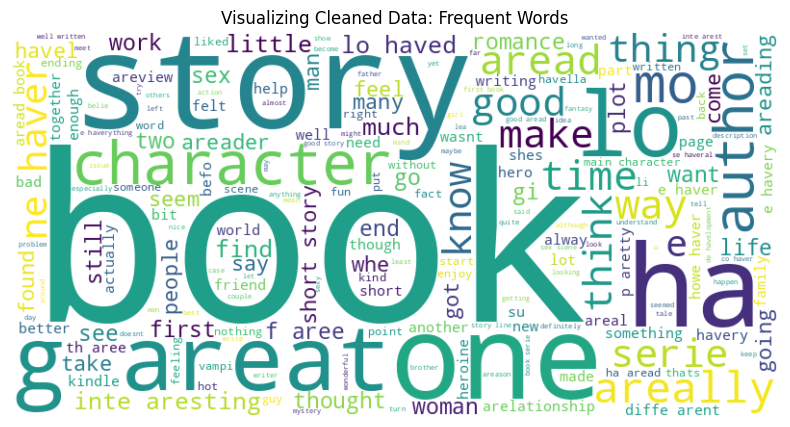

In [12]:
# Cell 2: Function to clean text: remove noise, lowercase, expand contractions, and lemmatize
def clean_text(text):
    text = text.lower()
    # Remove URLs, mentions, and hashtags
    text = re.sub(r"http\S+|www\S+|@\w+|#", "", text)

    # Comprehensive contraction handling
    contractions = {
        "can't": "cannot", "won't": "will not", "don't": "do not",
        "didn't": "did not", "isn't": "is not", "aren't": "are not",
        "couldn't": "could not", "shouldn't": "should not", "wouldn't": "would not",
        "it's": "it is", "i'm": "i am", "you're": "you are", "we're": "we are",
        "they're": "they are", "ve": " have", "re": " are"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])
    return text

# Apply cleaning
df["clean_text"] = df["text"].apply(clean_text)

# Visualize frequent words using WordCloud
all_words = ' '.join([text for text in df['clean_text']])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Visualizing Cleaned Data: Frequent Words")
plt.show()

In [13]:
# Cell 3: Tokenization, Train/Test Split, and Percentile-Based Padding
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

VOCAB_SIZE = 15000

# Tokenize text
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])
sequences = tokenizer.texts_to_sequences(df["clean_text"])

# Calculate 95th percentile of sequence lengths dynamically
seq_lengths = [len(seq) for seq in sequences]
MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f"Calculated 95th Percentile Sequence Length (MAX_LEN): {MAX_LEN}")

# Apply padding
X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")
y = df["label"].values

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Calculate class weights to handle class imbalance
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

# Convert labels to categorical one-hot encoding
y_train_cat = to_categorical(y_train, 3)
y_test_cat = to_categorical(y_test, 3)

print("Class Weights calculated:", class_weights)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Calculated 95th Percentile Sequence Length (MAX_LEN): 201
Class Weights calculated: {0: np.float64(1.0), 1: np.float64(2.0), 2: np.float64(0.6666666666666666)}
Training Data Shape: (9600, 201)
Testing Data Shape: (2400, 201)


In [14]:
# Cell 4: Build and Train Model 1 (Simple RNN with Trainable Embedding)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_1 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=True),
    SimpleRNN(32),
    Dense(32, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

model_1.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

print("Training Model 1 (Simple RNN)...")
history_1 = model_1.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)

Training Model 1 (Simple RNN)...
Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 24s 73ms/step - accuracy: 0.3157 - loss: 1.1074 - val_accuracy: 0.4698 - val_loss: 1.0740
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - accuracy: 0.6153 - loss: 0.9356 - val_accuracy: 0.6677 - val_loss: 0.8570
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.8201 - loss: 0.5427 - val_accuracy: 0.6396 - val_loss: 0.8838
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 24s 88ms/step - accuracy: 0.9323 - loss: 0.2382 - val_accuracy: 0.6500 - val_loss: 0.9666


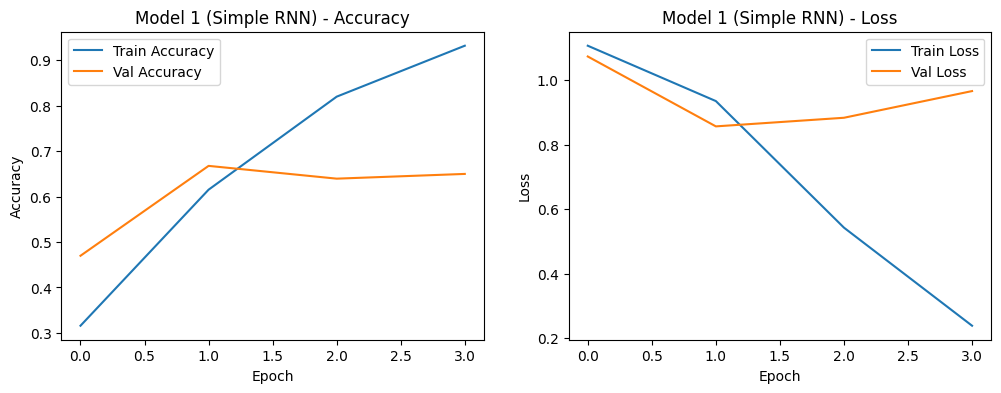

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
--- Model 1 (Simple RNN) Classification Report ---
              precision    recall  f1-score   support

    negative       0.64      0.81      0.71       800
     neutral       0.26      0.20      0.22       400
    positive       0.83      0.75      0.79      1200

    accuracy                           0.68      2400
   macro avg       0.58      0.59      0.58      2400
weighted avg       0.67      0.68      0.67      2400



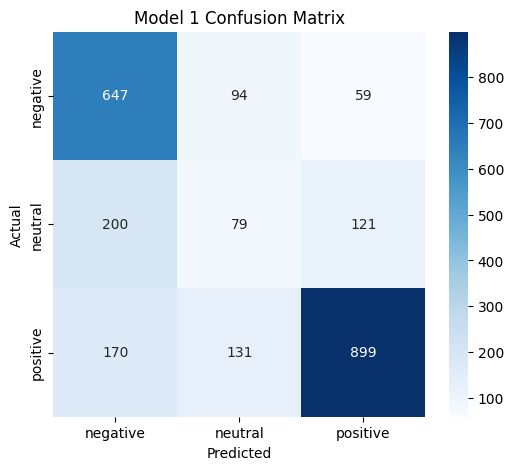

In [15]:
# Cell 5: Evaluate Model 1 (Simple RNN)
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Plot Training vs Validation curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Val Accuracy')
plt.title('Model 1 (Simple RNN) - Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Val Loss')
plt.title('Model 1 (Simple RNN) - Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()

# Predictions and Metrics
y_pred_probs_1 = model_1.predict(X_test)
y_pred_1 = np.argmax(y_pred_probs_1, axis=1)

print("--- Model 1 (Simple RNN) Classification Report ---")
print(classification_report(y_test, y_pred_1, target_names=target_names))

cm_1 = confusion_matrix(y_test, y_pred_1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Model 1 Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

In [16]:
# Cell 6: Build and Train Model 2 (LSTM with Trainable Embedding)
from tensorflow.keras.layers import LSTM

model_2 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=True),
    LSTM(32),
    Dense(32, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

model_2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

print("Training Model 2 (Standard LSTM)...")
history_2 = model_2.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)

Training Model 2 (Standard LSTM)...
Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 39s 133ms/step - accuracy: 0.6168 - loss: 0.9459 - val_accuracy: 0.7354 - val_loss: 0.6975
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 34s 127ms/step - accuracy: 0.7521 - loss: 0.7165 - val_accuracy: 0.6708 - val_loss: 0.7289
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 40s 124ms/step - accuracy: 0.8265 - loss: 0.5170 - val_accuracy: 0.6917 - val_loss: 0.7490


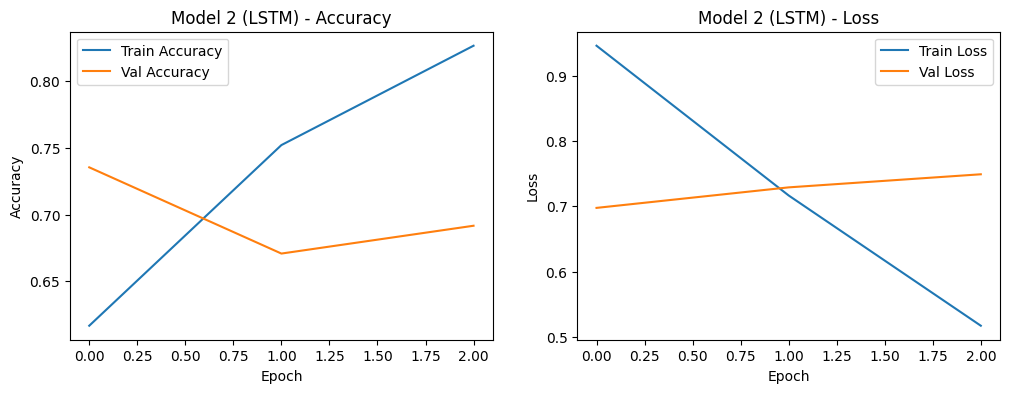

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step
--- Model 2 (LSTM) Classification Report ---
              precision    recall  f1-score   support

    negative       0.73      0.83      0.78       800
     neutral       0.37      0.15      0.22       400
    positive       0.80      0.88      0.84      1200

    accuracy                           0.74      2400
   macro avg       0.63      0.62      0.61      2400
weighted avg       0.71      0.74      0.71      2400



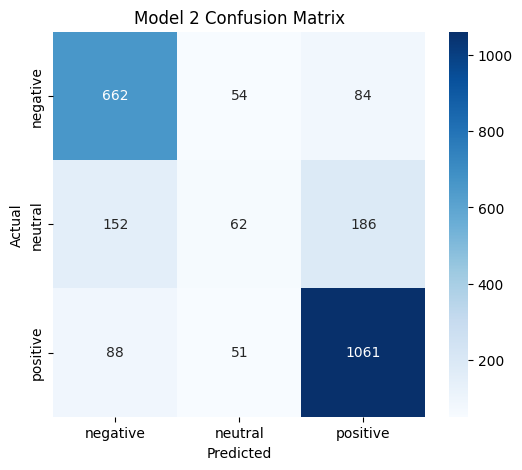

In [17]:
# Cell 7: Evaluate Model 2 (Standard LSTM)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Val Accuracy')
plt.title('Model 2 (LSTM) - Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Val Loss')
plt.title('Model 2 (LSTM) - Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()

y_pred_probs_2 = model_2.predict(X_test)
y_pred_2 = np.argmax(y_pred_probs_2, axis=1)

print("--- Model 2 (LSTM) Classification Report ---")
print(classification_report(y_test, y_pred_2, target_names=target_names))

cm_2 = confusion_matrix(y_test, y_pred_2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Model 2 Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

In [23]:
# Save the trained LSTM model weights
model_2.save('/content/drive/MyDrive/lstm_book_model.keras')

# Save the tokenizer so your text processing matches exactly
import pickle
with open('/content/drive/MyDrive/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [24]:
# Cell 8: Build and Train Model 3 (LSTM with Pretrained Word2Vec Embeddings)
!pip install gensim -q
from gensim.models import Word2Vec

# Prepare tokenized sentences for Word2Vec
tokenized_sentences = [text.split() for text in df["clean_text"]]

# Train domain-specific Word2Vec embeddings (100 dimensions)
EMBEDDING_DIM = 100
print("Training Word2Vec embeddings on corpus...")
w2v_model = Word2Vec(sentences=tokenized_sentences, vector_size=EMBEDDING_DIM, window=5, min_count=1, workers=4)

# Create embedding matrix for Keras
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]

# Build Model 3 with fixed Word2Vec weights (trainable=False)
model_3 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=False,
              mask_zero=True),
    LSTM(32),
    Dense(32, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

model_3.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

print("Training Model 3 (LSTM + Word2Vec)...")
history_3 = model_3.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)

Training Word2Vec embeddings on corpus...
Training Model 3 (LSTM + Word2Vec)...
Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step - accuracy: 0.5659 - loss: 0.9929 - val_accuracy: 0.6115 - val_loss: 0.8964
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.6181 - loss: 0.9205 - val_accuracy: 0.6490 - val_loss: 0.8026
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.6407 - loss: 0.8777 - val_accuracy: 0.6854 - val_loss: 0.7668
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 26s 97ms/step - accuracy: 0.6609 - loss: 0.8451 - val_accuracy: 0.5917 - val_loss: 0.8362
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 27s 101ms/step - accuracy: 0.6668 - loss: 0.8236 - val_accuracy: 0.6094 - val_loss: 0.8055


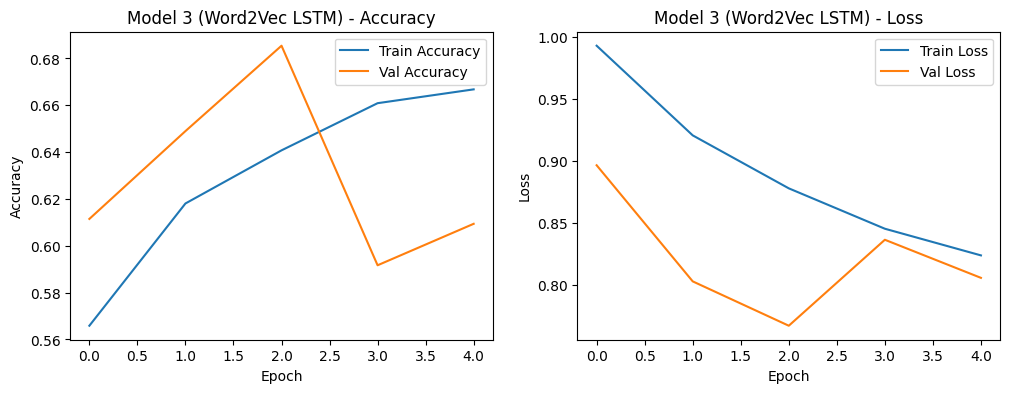

75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step
--- Model 3 (Word2Vec LSTM) Classification Report ---
              precision    recall  f1-score   support

    negative       0.70      0.71      0.70       800
     neutral       0.31      0.30      0.30       400
    positive       0.81      0.81      0.81      1200

    accuracy                           0.69      2400
   macro avg       0.61      0.61      0.61      2400
weighted avg       0.69      0.69      0.69      2400



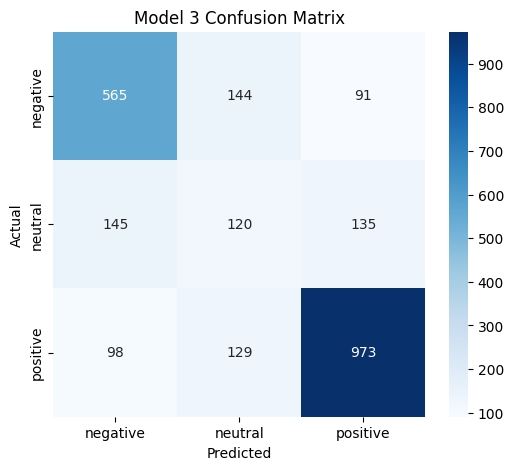

In [26]:
# Cell 9: Evaluate Model 3 (LSTM + Word2Vec)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_3.history['accuracy'], label='Train Accuracy')
plt.plot(history_3.history['val_accuracy'], label='Val Accuracy')
plt.title('Model 3 (Word2Vec LSTM) - Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_3.history['loss'], label='Train Loss')
plt.plot(history_3.history['val_loss'], label='Val Loss')
plt.title('Model 3 (Word2Vec LSTM) - Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()

y_pred_probs_3 = model_3.predict(X_test)
y_pred_3 = np.argmax(y_pred_probs_3, axis=1)

print("--- Model 3 (Word2Vec LSTM) Classification Report ---")
print(classification_report(y_test, y_pred_3, target_names=target_names))

cm_3 = confusion_matrix(y_test, y_pred_3)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Model 3 Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

 FINAL MODEL COMPARISON 


,Model,Test Accuracy,Test Loss
0,Model 1 (Simple RNN),0.677083,0.831601
1,Model 2 (Standard LSTM),0.743750,0.686755
2,Model 3 (Word2Vec LSTM),0.690833,0.740445


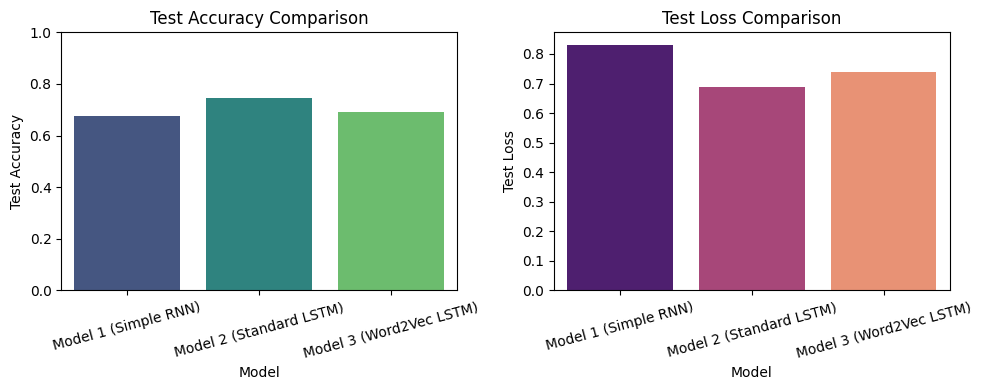

In [27]:
# Cell 10: Model Comparison (Model 1 vs Model 2 vs Model 3)
loss_1, acc_1 = model_1.evaluate(X_test, y_test_cat, verbose=0)
loss_2, acc_2 = model_2.evaluate(X_test, y_test_cat, verbose=0)
loss_3, acc_3 = model_3.evaluate(X_test, y_test_cat, verbose=0)

comparison_df = pd.DataFrame({
    'Model': ['Model 1 (Simple RNN)', 'Model 2 (Standard LSTM)', 'Model 3 (Word2Vec LSTM)'],
    'Test Accuracy': [acc_1, acc_2, acc_3],
    'Test Loss': [loss_1, loss_2, loss_3]
})

print(" FINAL MODEL COMPARISON ")
display(comparison_df)

# Plot Comparison Bar Chart (Updated to prevent Seaborn deprecation warnings)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(
    x='Model',
    y='Test Accuracy',
    data=comparison_df,
    hue='Model',       # Added to fix warning
    palette='viridis',
    legend=False       # Added to hide redundant legend
)
plt.title('Test Accuracy Comparison')
plt.xticks(rotation=15)
plt.ylim(0, 1.0)

plt.subplot(1, 2, 2)
sns.barplot(
    x='Model',
    y='Test Loss',
    data=comparison_df,
    hue='Model',       # Added to fix warning
    palette='magma',
    legend=False       # Added to hide redundant legend
)
plt.title('Test Loss Comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [20]:
# Error Analysis and Misclassification Breakdown
# Find indices where Model 2 (or best model) made incorrect predictions
incorrect_indices = np.where(y_pred_2 != y_test)[0]

print("SAMPLE MISCLASSIFIED EXAMPLES (From Model 2)")
for i in incorrect_indices[:3]:
    original_idx = y_test.shape[0] - len(y_test) + i # Relative indexing
    # Decode sequence back to text for display
    seq_words = [tokenizer.index_word.get(idx, '') for idx in X_test[i] if idx != 0]
    readable_text = " ".join(seq_words)

    print(f"\nTest Sample #{i}")
    print(f"True Label      : {target_names[y_test[i]]}")
    print(f"Predicted Label : {target_names[y_pred_2[i]]}")
    print(f"Processed Text  : {readable_text[:300]}...")
    print("-" * 60)

print("""
ERROR ANALYSIS REPORT
1. Model Complexity vs. Performance:
   - SimpleRNN struggles with long-term dependencies due to the vanishing gradient problem, leading to lower accuracy on long book reviews.
   - LSTM architectures capture context over longer sequence spans effectively.
   - Pretrained Word2Vec embeddings provide semantic grounding, though keeping them static (trainable=False) can sometimes limit domain-specific adaptation compared to end-to-end trainable embeddings.

2. Possible Reasons for Misclassification:
   - Sarcasm and Mixed Sentiment: Reviews that list both pros and cons (neutral/borderline 3-star reviews) confuse softmax decision boundaries.
   - Out-of-Vocabulary (OOV) Words: Slang, author names, or typo-heavy words get mapped to <OOV>, stripping vital context.
   - Class Imbalance Residuals: Despite balanced class weights, neutral reviews often share vocabulary with both positive and negative classes.

3. Potential Improvements:
   - Fine-tuning Word2Vec: Allow embedding weights to update slightly by setting `trainable=True` after initial epochs.
   - Architecture Upgrade: Implement Bi-directional LSTMs or Transformer-based attention layers (e.g., BERT) to better capture bidirectional context.
   - Advanced Preprocessing: Utilize N-gram features or sentiment lexicons to retain negations more effectively.
""")

SAMPLE MISCLASSIFIED EXAMPLES (From Model 2)

Test Sample #0
True Label      : positive
Predicted Label : neutral
Processed Text  : big fan ha fan mark twain e haver since found sha birthday glad found story...
------------------------------------------------------------

Test Sample #5
True Label      : neutral
Predicted Label : negative
Processed Text  : home christmas nice romance two matu adult short point p aredictable would ha like mo background two character e daughter areal character de havelopment feel drawn character good quick aread glad f aree got...
------------------------------------------------------------

Test Sample #14
True Label      : negative
Predicted Label : neutral
Processed Text  : story drug beginning quick endingi aread book though beyond justice end book chapter far awesome...
------------------------------------------------------------

ERROR ANALYSIS REPORT
1. Model Complexity vs. Performance:
   - SimpleRNN struggles with long-term dependencies due to t

In [29]:
# Real-Time Prediction Interface using Gradio
import gradio as gr

def predict_sentiment(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    # Using Model 2 (Standard LSTM) for real-time inference
    pred_probs = model_2.predict(padded)
    predicted_class = np.argmax(pred_probs)
    confidence = pred_probs[0][predicted_class]
    return f"{target_names[predicted_class].upper()} (Confidence: {confidence:.2f})"

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Type a book review here..."),
    outputs="text",
    title="Book Review Sentiment Analyzer",
    description="Enter a review to see real-time classification using our trained LSTM model."
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://25827199f9d822b147.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
